# Connecting Probability Theory to ML Model Implementations

## 📚 Learning Objectives

By completing this notebook, you will:
- Connect probability theory to ML model implementations
- Understand how probability distributions are used in ML
- Apply probability concepts to model training and evaluation
- See probability theory in action in real ML scenarios

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 05 "Introduction to Machine Learning" — the vocabulary of models, features and predictions; this notebook rewrites all of it in probability.

**Used later in:** Course 08 (AIAT 122) — Unit 4, lesson 02 "Implementing a VAE for Anomaly Detection" — a model that is probabilistic end to end.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Connecting probability theory to ML model implementations

---

## Introduction

**Probability theory** is fundamental to machine learning. ML models make probabilistic predictions, loss functions are based on probability, and uncertainty quantification relies on probability distributions.


---

## 📌 Real case: modern networks are confidently wrong

A classifier that outputs 0.95 should be right about 95% of the time on the cases where it says 0.95. That
property is called **calibration**, and in 2017 Chuan Guo, Geoff Pleiss, Yu Sun and Kilian Weinberger
showed in *"On Calibration of Modern Neural Networks"* (ICML) that modern deep networks have largely lost
it. Networks from a decade earlier were reasonably calibrated; the deeper, wider, batch-normalised models
that replaced them are **systematically overconfident** — more accurate than their predecessors and worse
at knowing when they are wrong. The authors trace it to depth, width, weight decay and batch normalisation,
and show that a one-parameter post-processing step, **temperature scaling**, fixes most of it.

That matters precisely because of what this notebook is about. A probability is only worth more than a
label if it is *true*. `predict_proba` will always hand you a number between 0 and 1; whether that number
means anything is a separate question that has to be measured.

**What goes wrong without this.** The right-hand panel below prints the useful fact: **29% of the held-out
biopsies receive a predicted probability between 0.2 and 0.8** — cases where the model is honestly unsure.
A 0/1 label would conceal every one of them. But that honesty is only worth having if a 0.7 really means
0.7, which is a claim about calibration, not about accuracy.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: scipy.stats plus sklearn's LogisticRegression and GaussianNB —
# the two classifiers whose probabilistic hearts this lesson opens up —
# and the real datasets they are trained on.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import warnings
warnings.filterwarnings('ignore')

# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nConnecting Probability Theory to ML Model Implementations")
print("=" * 60)


✅ Libraries imported!

Connecting Probability Theory to ML Model Implementations


## Part 1: Probability in Classification (Logistic Regression)


Part 1: Probability in Classification (Logistic Regression)

Dataset: 569 real biopsies, features = ['mean radius', 'mean texture'] (standardized)
Class balance: 357 benign / 212 malignant

Logistic Regression Model:
  Training samples: 398
  Test samples: 171

Sample predictions:
  Sample 1: True class=0, Predicted prob=0.6172, Predicted class=1
  Sample 2: True class=1, Predicted prob=0.8071, Predicted class=1
  Sample 3: True class=1, Predicted prob=0.9518, Predicted class=1
  Sample 4: True class=0, Predicted prob=0.0068, Predicted class=0
  Sample 5: True class=0, Predicted prob=0.4954, Predicted class=0

Cross-entropy loss (negative log-likelihood): 0.2495


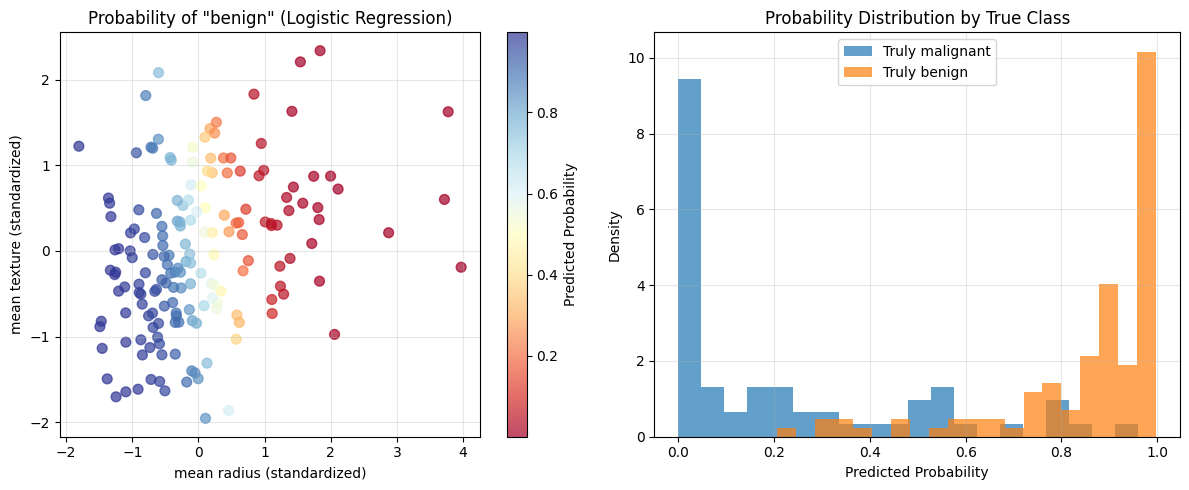


📊 Read the figure:
  - Left: the colour does not flip from blue to red at a line - it fades through pale
    yellow across a BAND running top to bottom near radius = 0.3. That band is the
    model's uncertainty. It is tilted: at high texture a tumour turns red at a
    SMALLER radius, because the two measurements pile up as evidence together.
  - Right: the two histograms pile up at the ends, but 29% of the held-out biopsies
    get a predicted probability between 0.2 and 0.8 - cases where the model is
    honestly unsure. A plain 0/1 label would hide that; a probability does not.

✅ Probability in classification demonstrated!


In [2]:
# Logistic regression outputs PROBABILITIES, not just labels — and its training loss
# (cross-entropy) is the negative log-likelihood from earlier in this unit.

print("=" * 60)
print("Part 1: Probability in Classification (Logistic Regression)")
print("=" * 60)

# Real data: Wisconsin Breast Cancer study - 569 tumour biopsies, real diagnoses.
# We keep two of the 30 measurements so the decision surface can be drawn in 2D.
cancer = load_breast_cancer()
feature_a, feature_b = "mean radius", "mean texture"
cols = [list(cancer.feature_names).index(feature_a), list(cancer.feature_names).index(feature_b)]
X = StandardScaler().fit_transform(cancer.data[:, cols])
y = cancer.target                      # 1 = benign, 0 = malignant (real diagnoses)

print(f"\nDataset: {X.shape[0]} real biopsies, features = ['{feature_a}', '{feature_b}'] (standardized)")
print(f"Class balance: {np.bincount(y)[1]} benign / {np.bincount(y)[0]} malignant")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train logistic regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Get probability predictions (this is probability theory in action!)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"\nLogistic Regression Model:")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"\nSample predictions:")
for i in range(5):
    print(f"  Sample {i+1}: True class={y_test[i]}, Predicted prob={y_proba[i]:.4f}, Predicted class={y_pred[i]}")

# Cross-entropy loss (based on probability)
loss = log_loss(y_test, y_proba)
print(f"\nCross-entropy loss (negative log-likelihood): {loss:.4f}")

# Visualize probability predictions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=y_proba, cmap='RdYlBu', s=50, alpha=0.7)
plt.colorbar(scatter, label='Predicted Probability')
plt.xlabel(f'{feature_a} (standardized)')
plt.ylabel(f'{feature_b} (standardized)')
plt.title('Probability of "benign" (Logistic Regression)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_proba[y_test == 0], bins=20, alpha=0.7, label='Truly malignant', density=True)
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.7, label='Truly benign', density=True)
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Probability Distribution by True Class')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

uncertain = np.mean((y_proba > 0.2) & (y_proba < 0.8))
print("\n📊 Read the figure:")
print("  - Left: the colour does not flip from blue to red at a line - it fades through pale")
print("    yellow across a BAND running top to bottom near radius = 0.3. That band is the")
print("    model's uncertainty. It is tilted: at high texture a tumour turns red at a")
print("    SMALLER radius, because the two measurements pile up as evidence together.")
print(f"  - Right: the two histograms pile up at the ends, but {uncertain:.0%} of the held-out biopsies")
print("    get a predicted probability between 0.2 and 0.8 - cases where the model is")
print("    honestly unsure. A plain 0/1 label would hide that; a probability does not.")

print("\n✅ Probability in classification demonstrated!")

## Part 2: Bayesian Inference in ML (Naive Bayes)



Part 2: Bayesian Inference in ML (Naive Bayes)

Naive Bayes Model (Bayesian Classification):
  Class priors: [0.3718593 0.6281407]
  Uses Bayes' theorem for classification

Sample predictions:
  Sample 1: True class=0, Bayesian prob=0.6835
  Sample 2: True class=1, Bayesian prob=0.8539
  Sample 3: True class=1, Bayesian prob=0.9615
  Sample 4: True class=0, Bayesian prob=0.0003
  Sample 5: True class=0, Bayesian prob=0.5650

Cross-entropy loss (Naive Bayes): 0.2430


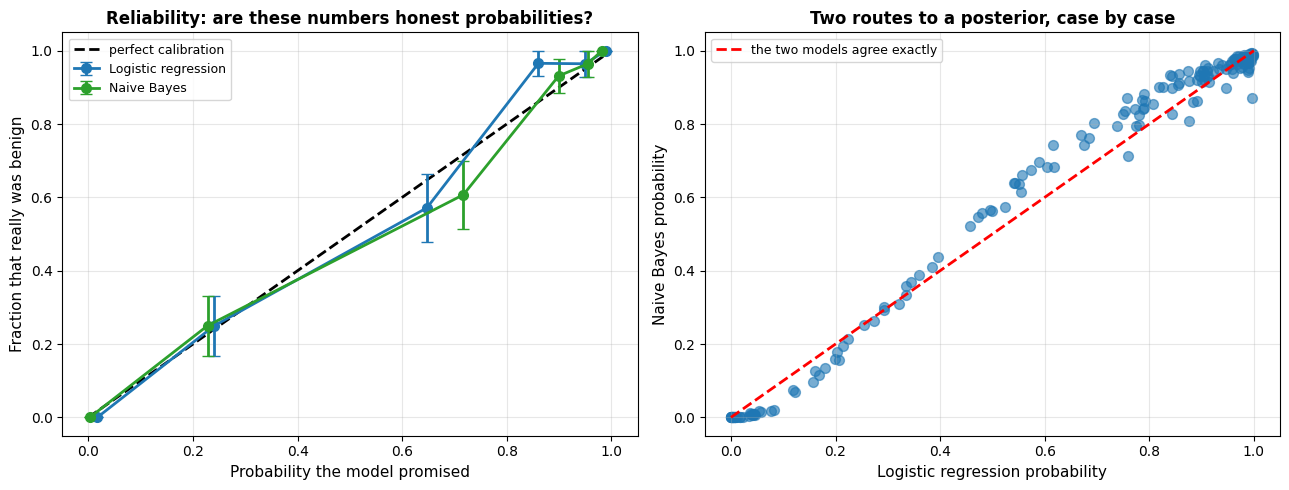


Expected calibration error (mean |promise - reality|):
  Logistic regression: 0.039      Naive Bayes: 0.032
  Cross-entropy loss:  0.2495   Naive Bayes: 0.2430

📊 Read the figure:
  - Left: both curves hug the black diagonal, so on this dataset both models'
    probabilities are roughly honest - a 0.9 really does mean about 90% benign.
  - The clearest departure is the bin around p = 0.86: on those 29 cases logistic
    regression delivered 0.97, i.e. MORE benign cases than it promised (under-confident there).
    Look at the error bar before calling that miscalibration - with fewer than 30
    cases per bin the diagram cannot resolve a gap smaller than about 0.1. Guo et al.
    needed tens of thousands of images to make their claim.
  - Right: the points lie close to the red line, so the two models mostly agree; where
    they sit ABOVE it, Naive Bayes is the more confident of the two that a tumour is
    benign - and its independence assumption is what makes it that confident.

✅ Ba

In [3]:
# Naive Bayes is Bayes' theorem as a classifier: P(class|x) ∝ P(x|class)·P(class).
# Comparing its probabilities with logistic regression's shows two roads to the same posterior.

print("\n" + "=" * 60)
print("Part 2: Bayesian Inference in ML (Naive Bayes)")
print("=" * 60)

# Naive Bayes uses Bayes' theorem: P(class|features) ∝ P(features|class) * P(class)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Get probability predictions using Bayes' theorem
y_proba_nb = nb_model.predict_proba(X_test)[:, 1]

print(f"\nNaive Bayes Model (Bayesian Classification):")
print(f"  Class priors: {nb_model.class_prior_}")
print(f"  Uses Bayes' theorem for classification")
print(f"\nSample predictions:")
for i in range(5):
    print(f"  Sample {i+1}: True class={y_test[i]}, Bayesian prob={y_proba_nb[i]:.4f}")

# Compare with logistic regression
loss_nb = log_loss(y_test, y_proba_nb)
print(f"\nCross-entropy loss (Naive Bayes): {loss_nb:.4f}")

# Visualize.
# LEFT is a reliability diagram - the check the '⚠️ Where this breaks' section demands and
# the exact tool Guo et al. (2017) used. A second copy of the probability map from Part 1,
# recoloured, would have shown almost the same picture and answered no new question.
# RIGHT compares the two models' probabilities case by case.


def reliability(probabilities, truth, n_bins=6):
    """Group predictions into equal-sized bins; return (mean predicted, observed rate, n).

    WHY equal-sized (quantile) bins rather than fixed 0.1-wide ones: with 171 test cases,
    fixed bins leave some bins nearly empty, and an 'observed rate' over 3 cases is noise.
    """
    edges = np.quantile(probabilities, np.linspace(0, 1, n_bins + 1))
    which = np.digitize(probabilities, edges[1:-1])
    rows = []
    for b in range(n_bins):
        m = which == b
        if m.sum() > 0:
            rows.append((probabilities[m].mean(), truth[m].mean(), int(m.sum())))
    return np.array(rows)


plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='perfect calibration')
for probs, name, colr in [(y_proba, 'Logistic regression', 'tab:blue'),
                          (y_proba_nb, 'Naive Bayes', 'tab:green')]:
    rows = reliability(probs, y_test)
    pred, obs, counts = rows[:, 0], rows[:, 1], rows[:, 2]
    # Error bars: how much an observed rate can wobble with this few cases in a bin.
    err = np.sqrt(np.clip(obs * (1 - obs), 1e-9, None) / counts)
    plt.errorbar(pred, obs, yerr=err, fmt='o-', color=colr, linewidth=2, markersize=7,
                 capsize=4, label=name)
plt.xlabel('Probability the model promised', fontsize=11)
plt.ylabel('Fraction that really was benign', fontsize=11)
plt.title('Reliability: are these numbers honest probabilities?',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_proba, y_proba_nb, alpha=0.6, s=50)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='the two models agree exactly')
plt.xlabel('Logistic regression probability', fontsize=11)
plt.ylabel('Naive Bayes probability', fontsize=11)
plt.title('Two routes to a posterior, case by case', fontsize=12, fontweight='bold')
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Expected calibration error: the average gap between promise and reality, weighted by bin size.
def ece(probabilities, truth, n_bins=6):
    rows = reliability(probabilities, truth, n_bins)
    return float(np.sum(rows[:, 2] / len(truth) * np.abs(rows[:, 0] - rows[:, 1])))


ece_lr, ece_nb = ece(y_proba, y_test), ece(y_proba_nb, y_test)
gap_lr = reliability(y_proba, y_test)
worst = gap_lr[np.argmax(np.abs(gap_lr[:, 0] - gap_lr[:, 1]))]
print(f"\nExpected calibration error (mean |promise - reality|):")
print(f"  Logistic regression: {ece_lr:.3f}      Naive Bayes: {ece_nb:.3f}")
print(f"  Cross-entropy loss:  {loss:.4f}   Naive Bayes: {loss_nb:.4f}")

print("\n📊 Read the figure:")
print("  - Left: both curves hug the black diagonal, so on this dataset both models'")
print("    probabilities are roughly honest - a 0.9 really does mean about 90% benign.")
_dir = "MORE benign cases than it promised (under-confident there)" if worst[1] > worst[0] \
    else "fewer benign cases than it promised (over-confident there)"
print(f"  - The clearest departure is the bin around p = {worst[0]:.2f}: on those {int(worst[2])} cases logistic")
print(f"    regression delivered {worst[1]:.2f}, i.e. {_dir}.")
print("    Look at the error bar before calling that miscalibration - with fewer than 30")
print("    cases per bin the diagram cannot resolve a gap smaller than about 0.1. Guo et al.")
print("    needed tens of thousands of images to make their claim.")
print("  - Right: the points lie close to the red line, so the two models mostly agree; where")
print("    they sit ABOVE it, Naive Bayes is the more confident of the two that a tumour is")
print("    benign - and its independence assumption is what makes it that confident.")


print("\n✅ Bayesian inference in ML demonstrated!")

**📖 What to see in the figure above.** The left panel is the only honest way to ask
whether a number like 0.9 *means* 0.9. Each marker takes all the test cases the model gave a
similar probability to, and plots the promise against what actually happened; the black
diagonal is a model whose probabilities are true. Both curves stay close to it, so on this
dataset these are usable probabilities — but the error bars matter as much as the markers: with
under 30 cases in a bin, the diagram cannot see a miscalibration smaller than about 0.1, which
is exactly why the Guo et al. result needed enormous test sets. The right panel shows the two
models are not producing the same posterior: points above the red line are cases where Naive
Bayes is the more confident of the two.

## Part 3: Probability Distributions in Loss Functions



Part 3: Probability Distributions in Loss Functions

Loss Functions and Probability Distributions:
  1. Mean Squared Error (MSE) ↔ Gaussian distribution
  2. Cross-entropy loss ↔ Multinomial distribution
  3. Negative log-likelihood ↔ Maximum likelihood estimation

Regression on real patients:
  Held-out patients: 133
  True values (first 5): [219.  70. 202. 230. 111.]
  Predictions (first 5): [138.5 181.1 125.3 292.8 123.9]
  MSE: 2821.7510
  Estimated σ (std of residuals): 53.1202

  Residual mean: 3.7396 (small next to σ = 53.1; on HELD-OUT
    data there is no algebraic guarantee it is exactly zero)
  Residual skewness: -0.1248
  Shapiro-Wilk normality test on the residuals: p = 0.6534
  The residuals are consistent with the Gaussian assumption MSE encodes.


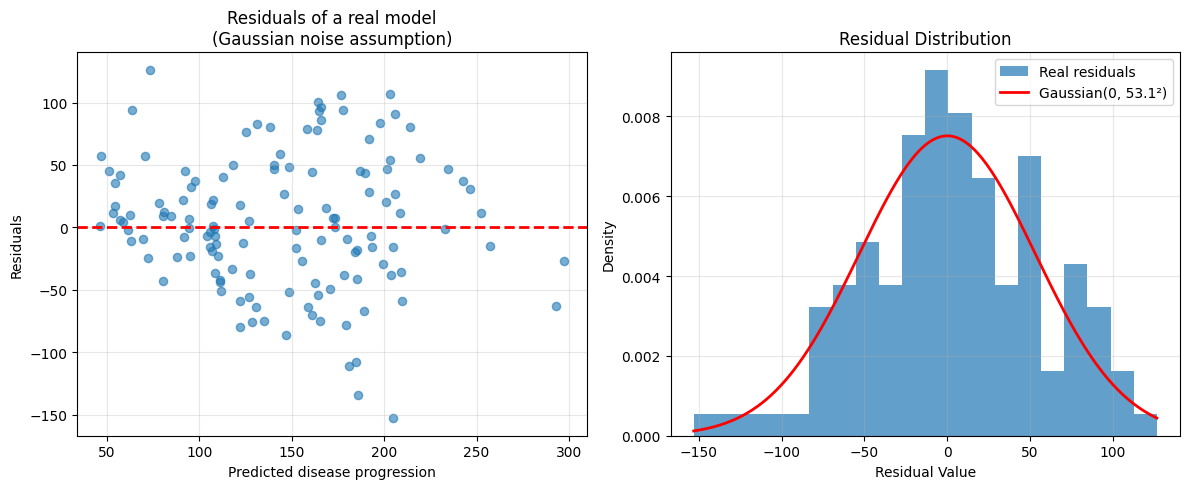


📊 Read the figure:
  - Left: the residuals sit above and below the red zero line with no tilt to the
    cloud (correlation with the prediction -0.07, p = 0.42) - the model has
    not missed an obvious trend.
  - Left, the part that is NOT fine: the cloud is visibly wider on the right. Errors
    on the half with higher predictions have spread 62, against 42 on the
    lower half. MSE assumes ONE constant sigma for every patient; this data says the
    sicker the predicted patient, the less certain the number is.
  - Right: the histogram of those same residuals with the Gaussian that MSE assumes
    drawn over it. The match is decent (skewness -0.12, Shapiro-Wilk
    p = 0.653), which is why minimising MSE here really is maximising a
    Gaussian likelihood rather than just a convenient formula.

✅ Probability distributions in loss functions demonstrated!


In [4]:
# Where losses come from: MSE is the Gaussian-noise log-likelihood in disguise.
# Checking that residuals look normal is checking the probabilistic assumption behind MSE.

print("\n" + "=" * 60)
print("Part 3: Probability Distributions in Loss Functions")
print("=" * 60)

# Many ML loss functions are derived from probability distributions
print("\nLoss Functions and Probability Distributions:")
print("  1. Mean Squared Error (MSE) ↔ Gaussian distribution")
print("  2. Cross-entropy loss ↔ Multinomial distribution")
print("  3. Negative log-likelihood ↔ Maximum likelihood estimation")

# Demonstrate on REAL regression errors: sklearn's diabetes study - 442 patients,
# 10 baseline measurements, target = disease progression one year later.
diabetes = load_diabetes()
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42
)
reg = LinearRegression().fit(Xr_train, yr_train)
y_true_reg = yr_test
y_pred_reg = reg.predict(Xr_test)

mse = np.mean((y_true_reg - y_pred_reg) ** 2)
print(f"\nRegression on real patients:")
print(f"  Held-out patients: {len(y_true_reg)}")
print(f"  True values (first 5): {np.round(y_true_reg[:5], 1)}")
print(f"  Predictions (first 5): {np.round(y_pred_reg[:5], 1)}")
print(f"  MSE: {mse:.4f}")

# MSE assumes Gaussian noise: y ~ N(y_hat, sigma^2)
# Maximizing that likelihood is exactly minimizing MSE.
sigma = np.sqrt(mse)
print(f"  Estimated σ (std of residuals): {sigma:.4f}")

residuals = y_true_reg - y_pred_reg

# Is the Gaussian assumption actually met by this real model?
shapiro_p = stats.shapiro(residuals).pvalue
print(f"\n  Residual mean: {residuals.mean():.4f} (small next to σ = {sigma:.1f}; on HELD-OUT")
print("    data there is no algebraic guarantee it is exactly zero)")
print(f"  Residual skewness: {stats.skew(residuals):.4f}")
print(f"  Shapiro-Wilk normality test on the residuals: p = {shapiro_p:.4f}")
print("  " + ("The residuals are consistent with the Gaussian assumption MSE encodes."
               if shapiro_p >= 0.05 else
               "The residuals depart from normality - MSE is still usable, but its"
               " probabilistic story is only approximate here."))

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_reg, residuals, s=35, alpha=0.6)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted disease progression')
plt.ylabel('Residuals')
plt.title('Residuals of a real model\n(Gaussian noise assumption)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
x = np.linspace(residuals.min(), residuals.max(), 200)
plt.hist(residuals, bins=20, density=True, alpha=0.7, label='Real residuals')
plt.plot(x, stats.norm.pdf(x, 0, sigma), 'r-', linewidth=2, label=f'Gaussian(0, {sigma:.1f}²)')
plt.xlabel('Residual Value')
plt.ylabel('Density')
plt.title('Residual Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Two checks the picture invites: is there a TREND in the residuals, and is their spread
# constant? MSE assumes "no" to the first and "yes" to the second.
trend = stats.pearsonr(y_pred_reg, residuals)
low_half = residuals[y_pred_reg < np.median(y_pred_reg)]
high_half = residuals[y_pred_reg >= np.median(y_pred_reg)]

print("\n📊 Read the figure:")
print("  - Left: the residuals sit above and below the red zero line with no tilt to the")
print(f"    cloud (correlation with the prediction {trend[0]:+.2f}, p = {trend[1]:.2f}) - the model has")
print("    not missed an obvious trend.")
print("  - Left, the part that is NOT fine: the cloud is visibly wider on the right. Errors")
print(f"    on the half with higher predictions have spread {high_half.std():.0f}, against {low_half.std():.0f} on the")
print("    lower half. MSE assumes ONE constant sigma for every patient; this data says the")
print("    sicker the predicted patient, the less certain the number is.")
print("  - Right: the histogram of those same residuals with the Gaussian that MSE assumes")
print(f"    drawn over it. The match is decent (skewness {stats.skew(residuals):.2f}, Shapiro-Wilk")
print(f"    p = {shapiro_p:.3f}), which is why minimising MSE here really is maximising a")
print("    Gaussian likelihood rather than just a convenient formula.")

print("\n✅ Probability distributions in loss functions demonstrated!")


**📖 What to see in the figure above.** These two panels are the audit of the sentence
"MSE assumes Gaussian noise". On the left, the residuals must look like a formless cloud around
zero — and they do have no tilt, but they are *not* equally wide everywhere: the spread grows
with the prediction, and constant-variance is part of what MSE assumes. On the right, the same
residuals are compared with the exact bell MSE assumes; the histogram tracks the red curve
closely, so minimising MSE here really is maximum likelihood and not just a convenient formula.
Two assumptions, one satisfied and one only approximately — which is the normal state of
affairs, and worth saying out loud rather than skipping.

---

## ⚠️ Where this breaks

- **Cross-entropy does not measure calibration.** Naive Bayes scores 0.2430 here and logistic regression
  0.2495 — Naive Bayes "wins", despite its independence assumption between `mean radius` and `mean texture`
  being false. A lower average loss can come from being sharper on easy cases while being badly
  overconfident on hard ones. To check calibration you need a reliability diagram or a Brier
  decomposition, not a single loss number.
- **Naive Bayes is famously good at ranking and bad at probabilities.** Its independence assumption makes it
  multiply evidence that is really shared, which pushes its outputs toward 0 and 1. Use its ordering; be
  careful with its numbers — and the same caution, per Guo and colleagues, now applies to deep networks.
- **MSE encodes an assumption that must be checked, and here it passes.** Part 3 tests it properly: the
  regression residuals have skewness −0.1248 and Shapiro–Wilk p = 0.6534, so the Gaussian noise model
  behind MSE is consistent with this data. That is a result, not a formality — the same test on Titanic
  fares (notebook 01) fails decisively, and MSE would be the wrong loss there.
- **Two of thirty features, chosen so the boundary could be drawn.** The 2D decision surface is a teaching
  device; the honest accuracy of this problem uses all 30 measurements. Do not compare the numbers here to
  the numbers in Unit 4.


---

## 💬 Discuss

1. 29% of held-out biopsies get a probability between 0.2 and 0.8. Design the workflow: what should the
   system actually *do* with those cases, and who decides the thresholds?
2. Guo and colleagues found that making networks deeper and more accurate made them *worse* at knowing when
   they were wrong. Which of those two properties would you optimise for in a medical triage system, and
   what would you tell the vendor who advertises only the first?
3. Naive Bayes reaches a lower cross-entropy than logistic regression while resting on an assumption that
   is false. What does that tell you about choosing models by a single number — and what second number
   would you insist on seeing?


## Summary

### Key Connections:
1. **Classification**: Models output probabilities (logistic regression, Naive Bayes)
2. **Loss Functions**: Derived from probability distributions (MSE ↔ Gaussian, cross-entropy ↔ multinomial)
3. **Bayesian ML**: Uses Bayes' theorem for inference (Naive Bayes, Bayesian neural networks)
4. **Uncertainty**: Probability distributions quantify prediction uncertainty
5. **Maximum Likelihood**: Training often maximizes likelihood (equivalent to minimizing negative log-likelihood)

### Probability in ML:
- **Predictions**: Probabilistic outputs, not just point estimates
- **Training**: Maximum likelihood estimation
- **Evaluation**: Likelihood-based metrics (log-likelihood, cross-entropy)
- **Uncertainty**: Probability distributions represent uncertainty

### Applications:
- Probabilistic predictions
- Uncertainty quantification
- Bayesian inference
- Model comparison
- Decision making under uncertainty

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - Connecting probability to ML practical content

## 📚 References

1. Cox, D. R. (1958). *The Regression Analysis of Binary Sequences*. Journal of the Royal Statistical Society, Series B, 20(2), 215–242.
2. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 4: Linear Models for Classification. Springer.
3. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/book1.html>
4. Liu, X., Chen, T., Da, L., Chen, C., Lin, Z., & Wei, H. (2025). *Uncertainty Quantification and Confidence Calibration in Large Language Models: A Survey*. arXiv. <https://arxiv.org/abs/2503.15850> — calibration and uncertainty for models whose probabilities are not to be taken at face value.
5. Angelopoulos & Bates (2022). *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*. arXiv. <https://arxiv.org/abs/2107.07511> — how to turn any model's scores into sets with a guaranteed error rate.
